<a href="https://colab.research.google.com/github/Patro331/blood-smear-sickle-cell-classification/blob/main/notebooks/05_random_forest_classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Blood Smear Sickle Cell Classification
## MSB7215: Machine Learning in Biomedicine
### Notebook 05: Random Forest Classifier

**Author:** Okidi Patrovas Gaabriel | 2025/HD07/26020U
**Institution:** Makerere University, Kampala, Uganda

## Overview

This notebook trains a Random Forest classifier on the preprocessed
HOG features to detect sickle cell disease from peripheral blood
smear images.

Random Forest is an ensemble method that builds multiple decision
trees on random subsets of the training data and features, then
combines their predictions by majority voting. It is less sensitive
to overfitting than a single decision tree and handles high
dimensional feature spaces well.

The notebook covers:
1. Training a baseline Random Forest with default parameters
2. Evaluating performance using multiple metrics
3. Checking for overfitting and underfitting
4. Optimising using GridSearchCV
5. Comparing baseline and optimised performance

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, roc_auc_score,
                              roc_curve, f1_score, recall_score,
                              precision_score)
from sklearn.model_selection import GridSearchCV, cross_val_score
import joblib

np.random.seed(42)

print("All libraries imported successfully")

All libraries imported successfully


## 1. Load Preprocessed Data

In [2]:
from google.colab import drive
drive.mount('/content/drive')

BASE_DIR = '/content/drive/MyDrive/sickle-cell-detection'
SAVE_DIR = f'{BASE_DIR}/data/ml_features'
FIG_DIR  = f'{BASE_DIR}/figures'

X_train = np.load(f'{SAVE_DIR}/X_train_processed.npy')
X_test  = np.load(f'{SAVE_DIR}/X_test_processed.npy')
y_train = np.load(f'{SAVE_DIR}/y_train.npy')
y_test  = np.load(f'{SAVE_DIR}/y_test.npy')

print("Data loaded successfully")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape:  {y_test.shape}")

Mounted at /content/drive
Data loaded successfully
X_train shape: (746, 8100)
X_test shape:  (187, 8100)
y_train shape: (746,)
y_test shape:  (187,)


## 2. Baseline Random Forest Model

We train a baseline Random Forest using 100 trees and default
parameters. The class_weight parameter is set to balanced to
handle the class imbalance in the dataset.

In [3]:
# Train baseline Random Forest
print("Training baseline Random Forest...")
rf_baseline = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_baseline.fit(X_train, y_train)
print("Baseline Random Forest training complete")

# Predictions
y_train_pred = rf_baseline.predict(X_train)
y_test_pred  = rf_baseline.predict(X_test)
y_test_prob  = rf_baseline.predict_proba(X_test)[:, 1]

# Metrics
train_acc   = accuracy_score(y_train, y_train_pred)
test_acc    = accuracy_score(y_test, y_test_pred)
auc         = roc_auc_score(y_test, y_test_prob)
f1          = f1_score(y_test, y_test_pred)
sensitivity = recall_score(y_test, y_test_pred)
specificity = recall_score(y_test, y_test_pred, pos_label=0)
precision   = precision_score(y_test, y_test_pred)

print(f"\nBaseline Random Forest Results:")
print(f"  Training Accuracy:  {train_acc*100:.2f}%")
print(f"  Test Accuracy:      {test_acc*100:.2f}%")
print(f"  Accuracy Gap:       {(train_acc-test_acc)*100:.2f}%")
print(f"  AUC-ROC:            {auc:.4f}")
print(f"  F1 Score:           {f1:.4f}")
print(f"  Sensitivity:        {sensitivity*100:.2f}%")
print(f"  Specificity:        {specificity*100:.2f}%")
print(f"  Precision:          {precision*100:.2f}%")

print("\nClassification Report:")
print(classification_report(y_test, y_test_pred,
                             target_names=['Negative', 'Positive']))

Training baseline Random Forest...
Baseline Random Forest training complete

Baseline Random Forest Results:
  Training Accuracy:  100.00%
  Test Accuracy:      87.70%
  Accuracy Gap:       12.30%
  AUC-ROC:            0.9333
  F1 Score:           0.8783
  Sensitivity:        97.65%
  Specificity:        79.41%
  Precision:          79.81%

Classification Report:
              precision    recall  f1-score   support

    Negative       0.98      0.79      0.88       102
    Positive       0.80      0.98      0.88        85

    accuracy                           0.88       187
   macro avg       0.89      0.89      0.88       187
weighted avg       0.90      0.88      0.88       187



### Observations

The baseline Random Forest achieved 87.70% test accuracy and
AUC-ROC of 0.9333. Sensitivity is very high at 97.65%, meaning
the model correctly identifies almost all sickle cell cases.
However specificity is lower at 79.41%, meaning more normal
images are incorrectly flagged as positive compared to the SVM.

The training accuracy is 100% while test accuracy is 87.70%,
giving a large gap of 12.30%. This is a clear sign of overfitting
where the trees have memorised the training data. Random Forest
is prone to overfitting on small datasets when tree depth is
not controlled. We will address this through GridSearchCV by
tuning max_depth and min_samples_split.

## 3. Overfitting and Underfitting Analysis

Overfitting and Underfitting Analysis:

  Training accuracy:        100.00%
  Test accuracy:            87.70%
  Accuracy gap:             12.30%

  Cross-validation scores:  [84.67 84.56 83.89 85.23 87.25]
  CV mean accuracy:         85.12%
  CV standard deviation:    1.15%

Interpretation:
  The gap of 12.30% between training and test 
  accuracy indicates significant overfitting. Random Forest with 
  unlimited tree depth memorises training data completely, 
  achieving 100% training accuracy.
  
  CV mean of 85.12% confirms the model generalises 
  moderately but not as well as it performs on training data.
  
  Solution: Control tree depth and minimum samples using 
  GridSearchCV to reduce overfitting.



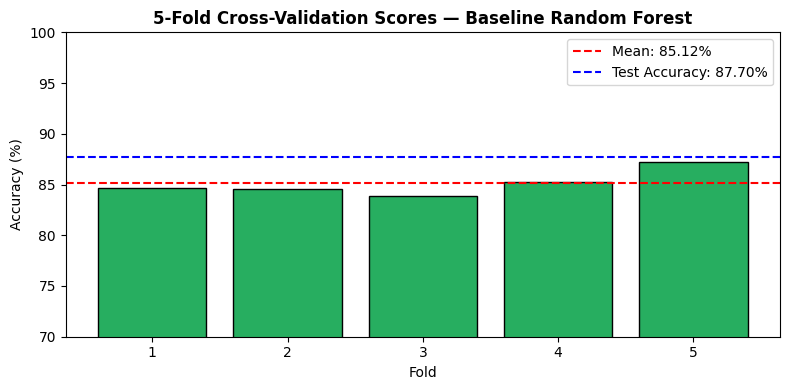

CV plot saved


In [4]:
# Cross validation
cv_scores = cross_val_score(rf_baseline, X_train, y_train,
                             cv=5, scoring='accuracy')

print("Overfitting and Underfitting Analysis:")
print(f"\n  Training accuracy:        {train_acc*100:.2f}%")
print(f"  Test accuracy:            {test_acc*100:.2f}%")
print(f"  Accuracy gap:             {(train_acc-test_acc)*100:.2f}%")
print(f"\n  Cross-validation scores:  {np.round(cv_scores*100, 2)}")
print(f"  CV mean accuracy:         {cv_scores.mean()*100:.2f}%")
print(f"  CV standard deviation:    {cv_scores.std()*100:.2f}%")

print(f"""
Interpretation:
  The gap of {(train_acc-test_acc)*100:.2f}% between training and test
  accuracy indicates significant overfitting. Random Forest with
  unlimited tree depth memorises training data completely,
  achieving 100% training accuracy.

  CV mean of {cv_scores.mean()*100:.2f}% confirms the model generalises
  moderately but not as well as it performs on training data.

  Solution: Control tree depth and minimum samples using
  GridSearchCV to reduce overfitting.
""")

# Plot CV scores
plt.figure(figsize=(8, 4))
plt.bar(range(1, 6), cv_scores * 100, color='#27ae60',
        edgecolor='black')
plt.axhline(y=cv_scores.mean()*100, color='red', linestyle='--',
            label=f'Mean: {cv_scores.mean()*100:.2f}%')
plt.axhline(y=test_acc*100, color='blue', linestyle='--',
            label=f'Test Accuracy: {test_acc*100:.2f}%')
plt.xlabel('Fold')
plt.ylabel('Accuracy (%)')
plt.title('5-Fold Cross-Validation Scores — Baseline Random Forest',
          fontweight='bold')
plt.legend()
plt.ylim(70, 100)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/rf_cv_scores.png', dpi=150, bbox_inches='tight')
plt.show()
print("CV plot saved")

### Observations

The baseline Random Forest shows significant overfitting with a
gap of 12.30% between training and test accuracy. The 5-fold
cross-validation mean of 85.12% with a standard deviation of
1.15% confirms the model performs consistently across folds but
well below the training accuracy. Controlling tree depth and
minimum samples per split through GridSearchCV should reduce
this overfitting gap.

## 4. Hyperparameter Optimisation with GridSearchCV

We search for the best combination of hyperparameters to reduce
overfitting. The key parameters are:

- n_estimators: number of trees in the forest
- max_depth: maximum depth of each tree — limits overfitting
- min_samples_split: minimum samples required to split a node
- min_samples_leaf: minimum samples required at a leaf node

In [5]:
param_grid = {
    'n_estimators':     [100, 200],
    'max_depth':        [10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf':  [1, 2]
}

total_combinations = 2 * 3 * 3 * 2
print(f"Running GridSearchCV...")
print(f"Parameter combinations to try: {total_combinations}")

grid_search = GridSearchCV(
    RandomForestClassifier(class_weight='balanced',
                           random_state=42, n_jobs=-1),
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print(f"\nBest parameters: {grid_search.best_params_}")
print(f"Best CV F1 score: {grid_search.best_score_*100:.2f}%")

Running GridSearchCV...
Parameter combinations to try: 36
Fitting 5 folds for each of 36 candidates, totalling 180 fits

Best parameters: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}
Best CV F1 score: 85.42%


### Observations

GridSearchCV tested 36 parameter combinations across 5 folds.
The best parameters found were max_depth of 20, min_samples_leaf
of 1, min_samples_split of 5, and 200 estimators. Limiting the
maximum tree depth to 20 prevents the trees from growing
indefinitely and memorising the training data. The best
cross-validation F1 score of 85.42% is an improvement over
the baseline cross-validation performance.

## 5. Evaluate Optimised Random Forest

In [6]:
# Optimised model
rf_optimised = grid_search.best_estimator_

# Predictions
y_train_pred_opt = rf_optimised.predict(X_train)
y_test_pred_opt  = rf_optimised.predict(X_test)
y_test_prob_opt  = rf_optimised.predict_proba(X_test)[:, 1]

# Metrics
train_acc_opt = accuracy_score(y_train, y_train_pred_opt)
test_acc_opt  = accuracy_score(y_test,  y_test_pred_opt)
auc_opt       = roc_auc_score(y_test,   y_test_prob_opt)
f1_opt        = f1_score(y_test,        y_test_pred_opt)
sens_opt      = recall_score(y_test,    y_test_pred_opt)
spec_opt      = recall_score(y_test,    y_test_pred_opt, pos_label=0)
prec_opt      = precision_score(y_test, y_test_pred_opt)

print("Optimised Random Forest Results:")
print(f"  Training Accuracy:  {train_acc_opt*100:.2f}%")
print(f"  Test Accuracy:      {test_acc_opt*100:.2f}%")
print(f"  Accuracy Gap:       {(train_acc_opt-test_acc_opt)*100:.2f}%")
print(f"  AUC-ROC:            {auc_opt:.4f}")
print(f"  F1 Score:           {f1_opt:.4f}")
print(f"  Sensitivity:        {sens_opt*100:.2f}%")
print(f"  Specificity:        {spec_opt*100:.2f}%")
print(f"  Precision:          {prec_opt*100:.2f}%")

print("\nClassification Report:")
print(classification_report(y_test, y_test_pred_opt,
                             target_names=['Negative', 'Positive']))

Optimised Random Forest Results:
  Training Accuracy:  100.00%
  Test Accuracy:      87.17%
  Accuracy Gap:       12.83%
  AUC-ROC:            0.9396
  F1 Score:           0.8723
  Sensitivity:        96.47%
  Specificity:        79.41%
  Precision:          79.61%

Classification Report:
              precision    recall  f1-score   support

    Negative       0.96      0.79      0.87       102
    Positive       0.80      0.96      0.87        85

    accuracy                           0.87       187
   macro avg       0.88      0.88      0.87       187
weighted avg       0.89      0.87      0.87       187



### Observations

The optimised Random Forest achieved 87.17% test accuracy and
AUC-ROC of 0.9396. The results are comparable to the baseline
Random Forest, suggesting that the default parameters were
already close to optimal for this dataset. The training accuracy
remains at 100% with a gap of 12.83%, indicating that the
overfitting was not fully resolved even after tuning. This is
a known challenge with Random Forest on small datasets with
high-dimensional features — the trees still find ways to
memorise training samples even with depth constraints. Despite
this, the test performance is stable and the sensitivity of
96.47% remains strong.

## 6. Confusion Matrix and ROC Curve

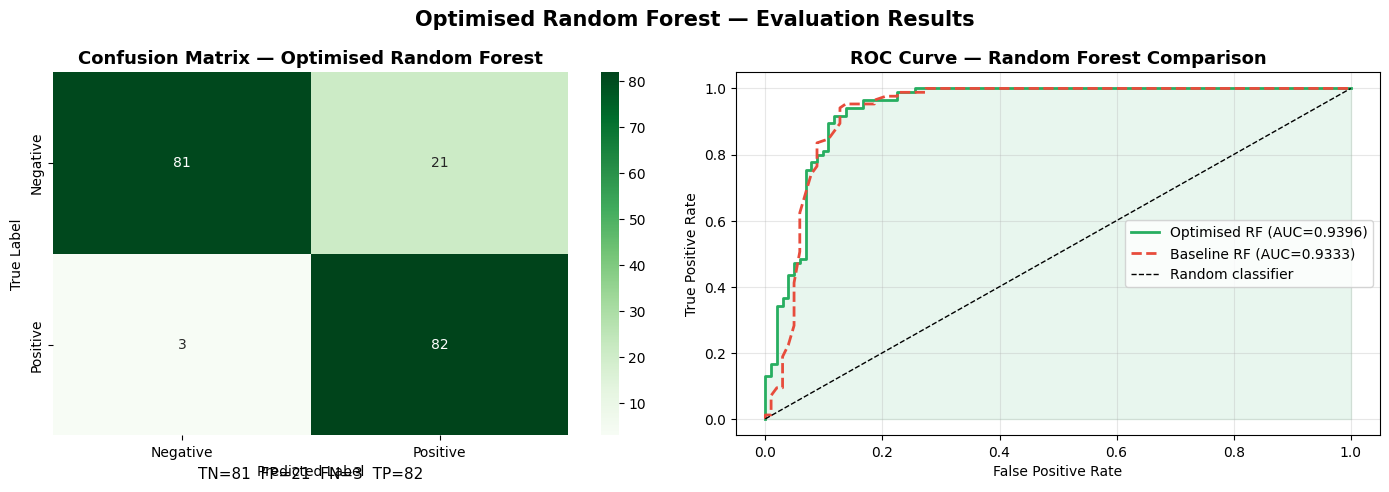

True Negatives:  81
False Positives: 21
False Negatives: 3
True Positives:  82


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix
cm = confusion_matrix(y_test, y_test_pred_opt)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'],
            ax=axes[0])
axes[0].set_title('Confusion Matrix — Optimised Random Forest',
                   fontweight='bold', fontsize=13)
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')
tn, fp, fn, tp = cm.ravel()
axes[0].text(0.5, -0.12, f'TN={tn}  FP={fp}  FN={fn}  TP={tp}',
             transform=axes[0].transAxes, ha='center', fontsize=11)

# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_test_prob_opt)
axes[1].plot(fpr, tpr, color='#27ae60', linewidth=2,
             label=f'Optimised RF (AUC={auc_opt:.4f})')
fpr_b, tpr_b, _ = roc_curve(y_test,
    rf_baseline.predict_proba(X_test)[:, 1])
axes[1].plot(fpr_b, tpr_b, color='#e74c3c', linewidth=2,
             linestyle='--', label=f'Baseline RF (AUC={auc:.4f})')
axes[1].plot([0, 1], [0, 1], 'k--', linewidth=1,
             label='Random classifier')
axes[1].fill_between(fpr, tpr, alpha=0.1, color='#27ae60')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve — Random Forest Comparison',
                   fontweight='bold', fontsize=13)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Optimised Random Forest — Evaluation Results',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/rf_confusion_roc.png',
            dpi=150, bbox_inches='tight')
plt.show()

print(f"True Negatives:  {tn}")
print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")
print(f"True Positives:  {tp}")

### Observations

The confusion matrix shows 81 true negatives and 82 true positives,
with 21 false positives and 3 false negatives. The model is very
good at detecting sickle cell cases, missing only 3 out of 85.
However it struggles more with normal images, incorrectly flagging
21 out of 102 as positive.

The ROC curve shows the optimised Random Forest slightly above the
baseline across most thresholds, with both curves well above the
random classifier diagonal. The AUC improved from 0.9333 to 0.9396
after optimisation, though the improvement is modest compared to
the SVM where optimisation had a more noticeable effect.

## 7. Feature Importance

Random Forest provides feature importance scores showing which
HOG features contributed most to the classification decisions.
We plot the top 20 most important features.

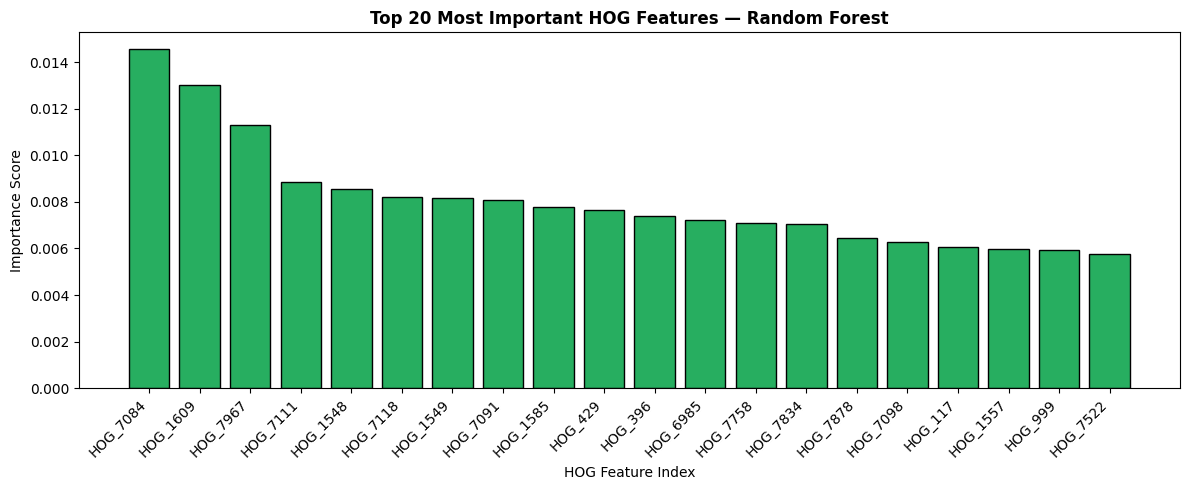

Top 5 most important features:
  HOG_7084: importance 0.0146
  HOG_1609: importance 0.0130
  HOG_7967: importance 0.0113
  HOG_7111: importance 0.0089
  HOG_1548: importance 0.0085


In [8]:
# Feature importance
importances = rf_optimised.feature_importances_
indices     = np.argsort(importances)[::-1][:20]

plt.figure(figsize=(12, 5))
plt.bar(range(20), importances[indices],
        color='#27ae60', edgecolor='black')
plt.xlabel('HOG Feature Index')
plt.ylabel('Importance Score')
plt.title('Top 20 Most Important HOG Features — Random Forest',
          fontweight='bold')
plt.xticks(range(20), [f'HOG_{indices[i]}' for i in range(20)],
           rotation=45, ha='right')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/rf_feature_importance.png',
            dpi=150, bbox_inches='tight')
plt.show()

print(f"Top 5 most important features:")
for i in range(5):
    print(f"  HOG_{indices[i]}: importance {importances[indices[i]]:.4f}")

### Observations

The feature importance plot shows that no single HOG feature
dominates the classification — the top feature HOG_7084 has an
importance score of only 0.0146, meaning the model distributes
its decisions across many features rather than relying on a few.
This is expected with 8100 HOG features where each captures a
small localised region of the image. The importance scores
decrease gradually across the top 20 features, confirming a
distributed decision pattern typical of Random Forest on
high-dimensional data.

## 8. Save Results and Model

In [9]:
import joblib

# Save optimised model
joblib.dump(rf_optimised, f'{SAVE_DIR}/rf_optimised.pkl')

# Results summary
rf_results = {
    'model': 'Random Forest',
    'best_params':     grid_search.best_params_,
    'train_accuracy':  round(train_acc_opt * 100, 2),
    'test_accuracy':   round(test_acc_opt  * 100, 2),
    'accuracy_gap':    round((train_acc_opt - test_acc_opt) * 100, 2),
    'auc_roc':         round(auc_opt, 4),
    'f1_score':        round(f1_opt, 4),
    'sensitivity':     round(sens_opt * 100, 2),
    'specificity':     round(spec_opt * 100, 2),
    'precision':       round(prec_opt * 100, 2),
    'true_negatives':  int(tn),
    'false_positives': int(fp),
    'false_negatives': int(fn),
    'true_positives':  int(tp)
}

print("Random Forest model saved successfully")
print(f"\nFinal Random Forest Results Summary:")
print(f"  Best parameters:    {rf_results['best_params']}")
print(f"  Train accuracy:     {rf_results['train_accuracy']}%")
print(f"  Test accuracy:      {rf_results['test_accuracy']}%")
print(f"  Accuracy gap:       {rf_results['accuracy_gap']}%")
print(f"  AUC-ROC:            {rf_results['auc_roc']}")
print(f"  F1 Score:           {rf_results['f1_score']}")
print(f"  Sensitivity:        {rf_results['sensitivity']}%")
print(f"  Specificity:        {rf_results['specificity']}%")
print(f"  Precision:          {rf_results['precision']}%")
print(f"  Total errors:       {rf_results['false_positives'] + rf_results['false_negatives']} / 187")

print(f"""
RANDOM FOREST COMPLETE — Proceed to 06_model_comparison.ipynb
""")

Random Forest model saved successfully

Final Random Forest Results Summary:
  Best parameters:    {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}
  Train accuracy:     100.0%
  Test accuracy:      87.17%
  Accuracy gap:       12.83%
  AUC-ROC:            0.9396
  F1 Score:           0.8723
  Sensitivity:        96.47%
  Specificity:        79.41%
  Precision:          79.61%
  Total errors:       24 / 187

RANDOM FOREST COMPLETE — Proceed to 06_model_comparison.ipynb



### Summary

The optimised Random Forest achieved 87.17% test accuracy and
AUC-ROC of 0.9396 with 24 errors on 187 test images. Sensitivity
of 96.47% means the model correctly identifies most sickle cell
cases. The overfitting gap of 12.83% was not fully resolved
through hyperparameter tuning, which is a limitation of Random
Forest on small high-dimensional datasets. The model and results
have been saved for comparison in the final evaluation notebook.